<a href="https://colab.research.google.com/github/Fauzi455/PembelajaranMesin_2026/blob/main/JS-05/TUGAS/Tugas%20Lab-2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Tugas Lab 2

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

In [22]:
from google.colab import files
uploaded = files.upload()

Saving spam.csv to spam.csv


In [27]:
df = pd.read_csv('spam.csv', encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN



 - Buatlah model klasfikasi Multinomial Naive Bayes dengan ketentuan,

    1. Menggunakan data spam.csv

    2. Fitur CountVectorizer dengan mengaktifkan stop_words

    3. Evaluasi hasilnya

In [31]:
#membersihkan dan memilih kolom yang relevan ('v1' adalah label dan 'v2' adalah teks)
if 'v1' in df.columns and 'v2' in df.columns:
    df = df[['v1', 'v2']].rename(columns={'v1': 'label', 'v2': 'text'})
elif 'Category' in df.columns and 'Message' in df.columns:
    df = df[['Category', 'Message']].rename(columns={'Category': 'label', 'Message': 'text'})

#memisahkan fitur (X) dan target (y)
X = df['text']
y = df['label'].map({'ham': 0, 'spam': 1})

#split data train & test (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

count_vec = CountVectorizer(stop_words='english')
X_train_cv = count_vec.fit_transform(X_train)
X_test_cv = count_vec.transform(X_test)

#melatih model
nb_cv = MultinomialNB()
nb_cv.fit(X_train_cv, y_train)

#prediksi dan evaluasi
y_pred_cv = nb_cv.predict(X_test_cv)

acc_cv = accuracy_score(y_test, y_pred_cv)
prec_cv = precision_score(y_test, y_pred_cv)
rec_cv = recall_score(y_test, y_pred_cv)
f1_cv = f1_score(y_test, y_pred_cv)

print(f"Accuracy  : {acc_cv * 100:.2f}%")
print(f"Precision : {prec_cv * 100:.2f}%")
print(f"Recall    : {rec_cv * 100:.2f}%")
print(f"F1-Score  : {f1_cv * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_cv, target_names=['ham', 'spam']))

Accuracy  : 98.45%
Precision : 96.00%
Recall    : 91.60%
F1-Score  : 93.75%

Classification Report:
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       903
        spam       0.96      0.92      0.94       131

    accuracy                           0.98      1034
   macro avg       0.97      0.96      0.96      1034
weighted avg       0.98      0.98      0.98      1034



  - Buatlah model klasfikasi Multinomial Naive Bayes dengan ketentuan,

    1. Menggunakan data spam.csv

    2. Fitur TF-IDF dengan mengaktifkan stop_words

    3. Evaluasi hasilnya dan bandingkan dengan hasil pada Tugas no 2.

    4. Berikan kesimpulan fitur mana yang terbaik pada kasus data spam.csv

In [35]:
#ekstraksi fitur dengan TfidfVectorizer dan stop_words diaktifkan
tfidf_vec = TfidfVectorizer(stop_words='english')
X_train_tfidf = tfidf_vec.fit_transform(X_train)
X_test_tfidf = tfidf_vec.transform(X_test)

#melatih model
nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_train_tfidf, y_train)

#prediksi & evaluasi
y_pred_tfidf = nb_tfidf.predict(X_test_tfidf)

acc_tfidf = accuracy_score(y_test, y_pred_tfidf)
prec_tfidf = precision_score(y_test, y_pred_tfidf)
rec_tfidf = recall_score(y_test, y_pred_tfidf)
f1_tfidf = f1_score(y_test, y_pred_tfidf)

print(f"Accuracy  : {acc_tfidf * 100:.2f}%")
print(f"Precision : {prec_tfidf * 100:.2f}%")
print(f"Recall    : {rec_tfidf * 100:.2f}%")
print(f"F1-Score  : {f1_tfidf * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_tfidf, target_names=['ham', 'spam']))

Accuracy  : 96.62%
Precision : 98.98%
Recall    : 74.05%
F1-Score  : 84.72%

Classification Report:
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       903
        spam       0.99      0.74      0.85       131

    accuracy                           0.97      1034
   macro avg       0.98      0.87      0.91      1034
weighted avg       0.97      0.97      0.96      1034



Perbandingan Evaluasi

   Metrik  CountVectorizer   TF-IDF
 Accuracy         0.984526 0.966151
Precision         0.960000 0.989796
   Recall         0.916031 0.740458
 F1-Score         0.937500 0.847162


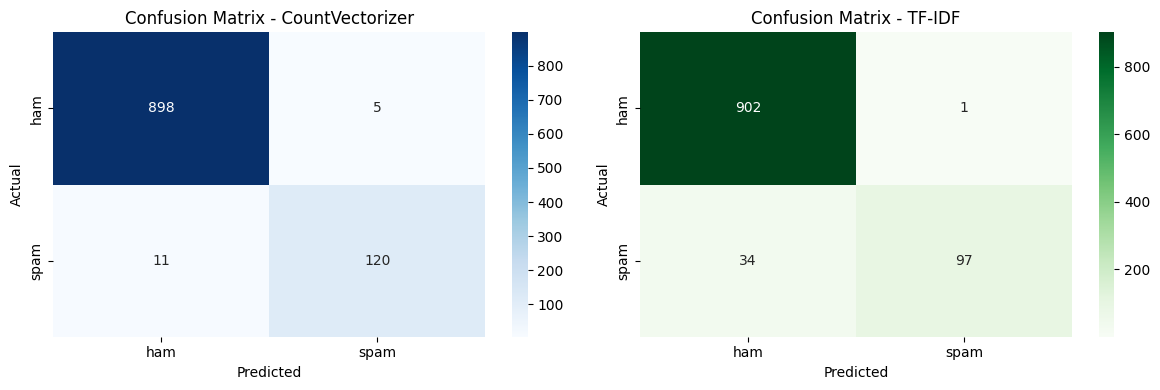

In [37]:
comparison_df = pd.DataFrame({
    'Metrik': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'CountVectorizer': [acc_cv, prec_cv, rec_cv, f1_cv],
    'TF-IDF': [acc_tfidf, prec_tfidf, rec_tfidf, f1_tfidf]
})

print("Perbandingan Evaluasi")
print()
print(comparison_df.to_string(index=False))

#visualisasi confusion Matrix berdampingan
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(confusion_matrix(y_test, y_pred_cv), annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'])
axes[0].set_title('Confusion Matrix - CountVectorizer')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, y_pred_tfidf), annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['ham', 'spam'], yticklabels=['ham', 'spam'])
axes[1].set_title('Confusion Matrix - TF-IDF')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

Fitur yang terbaik bergantung pada prioritas metrik bisnis/kebutuhan sistem, namun secara umum:

  1. Untuk akurasi dan deteksi keseluruhan, CountVectorizer lebih baik.karena menghasilkan nilai Recall dan F1-Score yang lebih tinggi dari TF-IDF
  
  2. Untuk keamanan pesan penting, TF-IDF lebih baik. Karena sistemnya sangat tidak mentolerir adanya pesan penting (ham) yang salah masuk ke folder Spam, sehingga TF-IDF adalah pilihan terbaik karena mencapai Precision mendekati 100%